# PART 5

Haikal Ali_1103223071_TK46GAB

# Linear Models and Regularization

Materi ini membahas model linear dan regularisasi. Fokus utamanya adalah linear regression, Ridge regression, Lasso regression, ElasticNet, teori regularisasi, polynomial regression, dan spline interpolation.

## Technical requirements

Disarankan menggunakan environment Python yang terpisah agar pekerjaan tidak bercampur dengan instalasi atau library Python lain. Kebutuhan teknis yang disebutkan pada materi adalah:

- Git >= 2.46.x
- Python >= 3.9.x
- Repository GitHub yang sudah di-clone dan environment Python yang dibuat dari file `requirements.txt`

## Introduction to linear models

Linear model digunakan untuk memahami hubungan antara variabel. Pada bagian ini, dataset sintetis dibuat menggunakan `make_regression()` dari scikit-learn. Dataset dibuat memiliki banyak fitur, noise, dan multicollinearity agar lebih menantang.

### Getting ready

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [2]:
X, y = make_regression(n_samples=1000,
                       n_features=100,
                       n_informative=10,
                       noise=20,
                       random_state=123)

In [3]:
for i in range(50, 100): # Make half the features correlated
  X[:, i] = X[:, i-50] + np.random.normal(0, 0.1, size=1000)

In [4]:
feature_names = [f'feature_{i}' for i in range(100)]

In [5]:
X_plot = X[:, 0].reshape(-1, 1)

In [6]:
y = y * 1000  # Scale up the target
y = (y + np.sin(X_plot.ravel()) * 150
     + np.exp(X_plot.ravel()/10))

In [7]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df_plot = pd.DataFrame({
  'feature_0': X_plot.ravel(), 'target': y
})

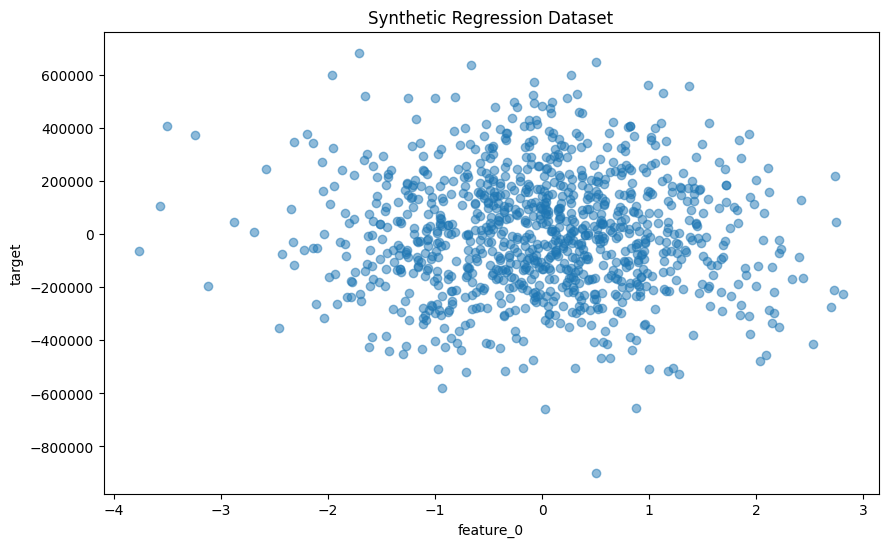

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y, alpha=0.5)
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Synthetic Regression Dataset')
plt.show()

Visualisasi tersebut hanya menggunakan satu fitur, yaitu `feature_0`, meskipun dataset sebenarnya memiliki 100 fitur.

### How to do it

Model linear regression dibuat dengan membagi data menjadi training dan testing set, lalu model dievaluasi menggunakan Mean Squared Error (MSE) dan R-squared (R²).

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2,
  random_state=123
)

In [11]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred = linear_model.predict(X_test)

In [13]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

Mean Squared Error: 48211623362.77
R-squared: 0.03


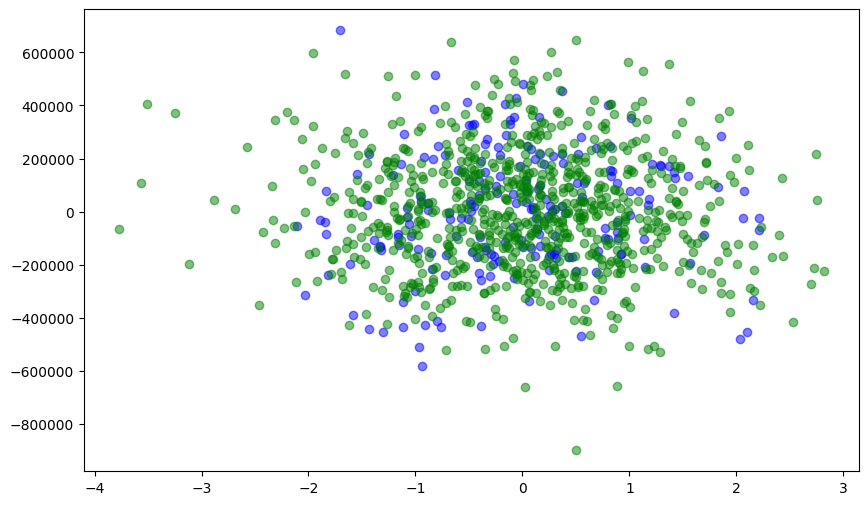

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(
  X_test[:, 0], y_test, color='blue',
  alpha=0.5, label='Test Data'
)
plt.scatter(
  X_train[:, 0], y_train, color='green',
  alpha=0.5, label='Train Data'
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


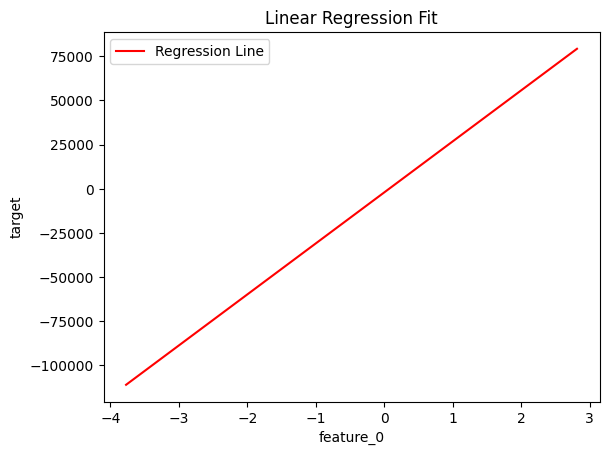

In [15]:
X_line = np.linspace(
  df['feature_0'].min(),
  df['feature_0'].max(), 100
).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()  # Set feature_0, leave others as 0
y_line = linear_model.predict(pd.DataFrame(
  X_line_full, columns=feature_names))
plt.plot(X_line, y_line, color='red', label='Regression Line')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

### How it works

Linear regression digunakan untuk memodelkan hubungan antara variabel target dan satu atau lebih fitur. Bentuk matematisnya:

\[
y = eta_0 + eta_1x_1 + eta_2x_2 + \cdots + eta_nx_n + \epsilon
\]

Keterangan:

- `y` adalah nilai prediksi
- `β0` adalah intercept
- `βn` adalah koefisien untuk setiap fitur
- `xn` adalah nilai fitur
- `ε` adalah error term

### There’s more

Setelah memahami linear regression dasar, materi menyebutkan teknik lanjutan seperti regularized regression dan logistic regression. Regularized regression mencakup Ridge dan Lasso regression untuk membantu mencegah overfitting dengan menambahkan penalti pada koefisien besar.

### Hands-on exercises

Alur umum latihan pada bagian ini:

1. Clone repository GitHub dan pastikan library yang dibutuhkan sudah terpasang.
2. Pilih dataset yang sesuai untuk regresi.
3. Bersihkan dataset dengan menangani missing value dan encoding categorical variables jika perlu.
4. Load `LinearRegression()` dari `sklearn.linear_model`.
5. Fit model menggunakan training data.
6. Gunakan `predict()` pada test data.
7. Hitung MSE dan R².
8. Buat plot untuk membandingkan nilai prediksi dan aktual atau residual.

## Ridge and Lasso regression

Ridge dan Lasso regression adalah teknik regularisasi untuk meningkatkan performa linear regression. Regularisasi membantu mencegah overfitting dengan menambahkan penalty term pada loss function.

### Getting ready

Ridge dan Lasso menggunakan dataset yang sama dari bagian linear model. Keduanya memiliki parameter `alpha` untuk mengatur kekuatan regularisasi.

### How to do it

In [16]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
ridge_model = Ridge(alpha=1.0)  # alpha controls regularization strength
ridge_model.fit(X_train, y_train)

Ridge()

In [18]:
lasso_model = Lasso(alpha=10.0, max_iter=10000, tol=0.001)
lasso_model.fit(X_train, y_train)

# Make predictions with both models
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

In [19]:
y_pred_linear = linear_model.predict(X_test)

In [20]:
metrics = {
  'Model': [
    'Ridge Regression',
    'Lasso Regression',
    'Linear Regression'
  ],
  'Mean Squared Error': [
    mean_squared_error(y_test, y_pred_ridge),
    mean_squared_error(y_test, y_pred_lasso),
    mean_squared_error(y_test, y_pred_linear)
  ],
  'R-squared': [
    r2_score(y_test, y_pred_ridge),
    r2_score(y_test, y_pred_lasso),
    r2_score(y_test, y_pred_linear)
  ]
}

In [21]:
metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.sort_values(
  'Mean Squared Error', ascending=True)

In [22]:
metrics_display_df = metrics_df.copy()
metrics_display_df['Mean Squared Error'] = metrics_display_df[
  'Mean Squared Error'
].map('{:.2f}'.format)
metrics_display_df['R-squared'] = metrics_display_df[
  'R-squared'
].map('{:.2f}'.format)
display(metrics_display_df)

,Model,Mean Squared Error,R-squared
0,Ridge Regression,46682873094.48,0.06
1,Lasso Regression,48056290641.10,0.03
2,Linear Regression,48211623362.77,0.03


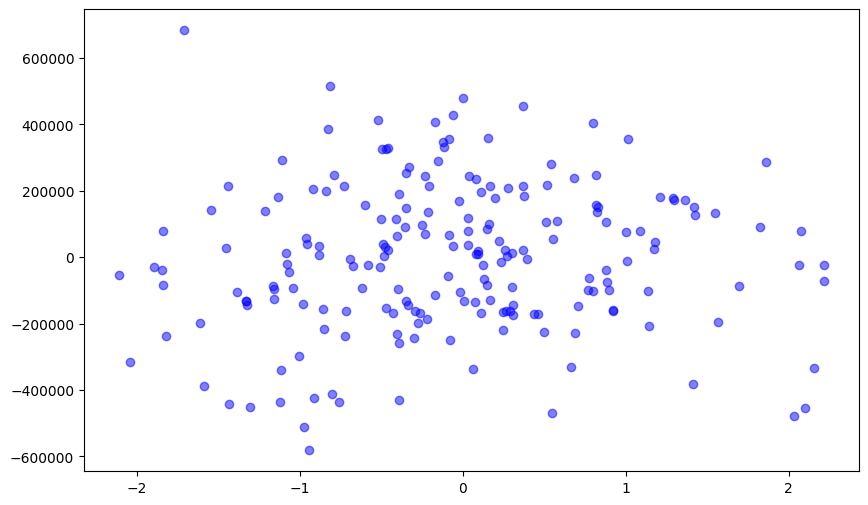

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(
  X_test[:, 0], y_test, color='blue',
  alpha=0.5, label='Test Data'
)

In [24]:
X_line = np.linspace(
  df['feature_0'].min(),
  df['feature_0'].max(), 100
).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()
X_line_df = pd.DataFrame(X_line_full, columns=feature_names)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


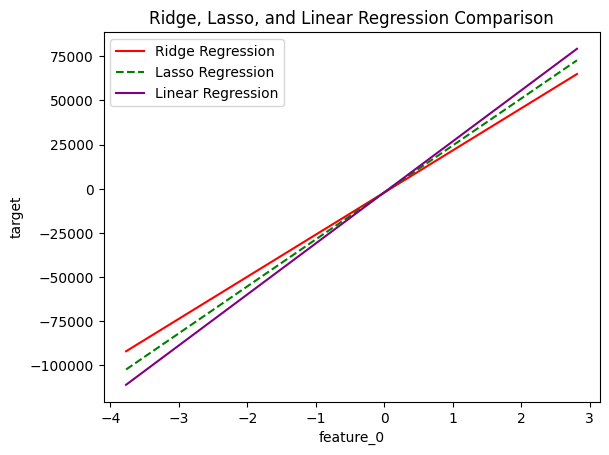

In [25]:
y_line_ridge = ridge_model.predict(X_line_df)
y_line_lasso = lasso_model.predict(X_line_df)
y_line_linear = linear_model.predict(X_line_df)
plt.plot(X_line, y_line_ridge, color='red',
         label='Ridge Regression')
plt.plot(X_line, y_line_lasso, color='green',
         linestyle='--', label='Lasso Regression')
plt.plot(X_line, y_line_linear, color='purple',
         label='Linear Regression')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Ridge, Lasso, and Linear Regression Comparison')
plt.legend()
plt.show()

### How it works

Ridge regression menambahkan penalti L2 pada loss function. Penalti ini menekan koefisien besar agar model tidak terlalu kompleks.

Lasso regression menambahkan penalti L1. Penalti L1 dapat membuat sebagian koefisien menjadi 0, sehingga Lasso juga dapat melakukan feature selection.

Ridge berguna ketika semua fitur tetap ingin dipertahankan tetapi pengaruhnya dikurangi. Lasso berguna ketika banyak fitur diduga tidak relevan atau redundant.

### Hands-on exercises

Alur umum latihan pada bagian ini:

1. Siapkan environment dan library.
2. Load dataset regresi.
3. Lakukan preprocessing jika diperlukan.
4. Load `Ridge` dari `sklearn.linear_model`.
5. Latih model dengan training data.
6. Hitung MSE dan R².
7. Load `Lasso` dari `sklearn.linear_model`.
8. Latih model dengan training data.
9. Hitung MSE dan R².
10. Analisis pengaruh regularisasi terhadap performa model.

## ElasticNet and regularization

ElasticNet adalah gabungan dari Ridge dan Lasso regression. Parameter `alpha` mengatur kekuatan regularisasi, sedangkan `l1_ratio` mengatur campuran antara penalti L1 dan L2.

### Getting ready

ElasticNet menggunakan class `ElasticNet()` dari `sklearn.linear_model`. Dataset yang digunakan sama seperti bagian Ridge dan Lasso.

### How to do it

In [26]:
from sklearn.linear_model import ElasticNet

In [27]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

In [28]:
coef_paths = []
labels = []

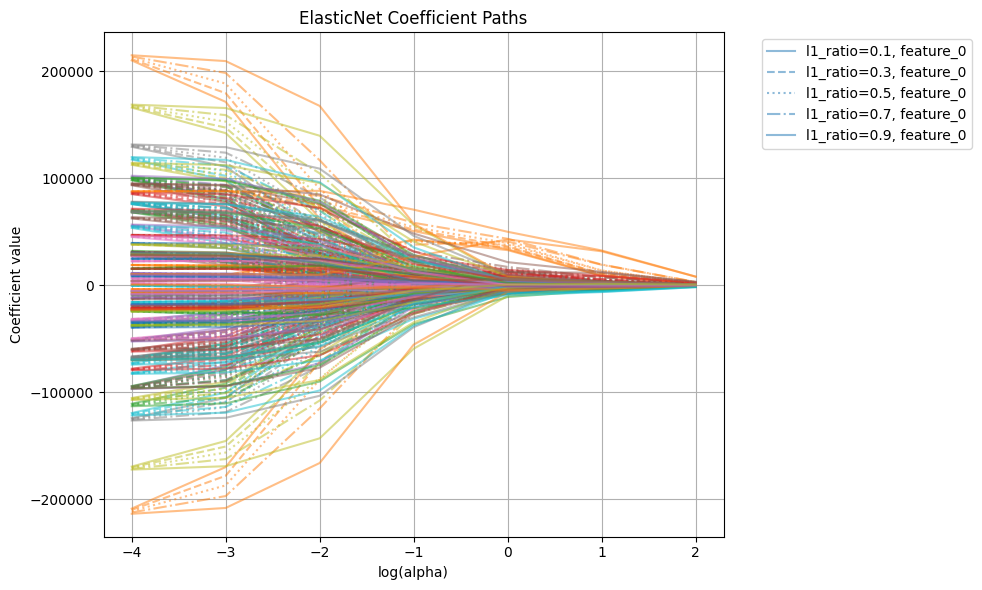

In [29]:
plt.figure(figsize=(10, 6))
for l1_ratio in l1_ratios:
  coefs = []
  for alpha in alphas:
    elastic_model = ElasticNet(
      alpha=alpha, l1_ratio=l1_ratio,
      random_state=123, max_iter=10000, tol=1e-4
    )
    elastic_model.fit(X_train, y_train)
    coefs.append(elastic_model.coef_)

  coef_paths.append(np.array(coefs))

  for feature_idx in range(X_train.shape[1]):
    plt.plot(
      np.log10(alphas),
      np.array(coefs)[:, feature_idx],
      label=(
        f'l1_ratio={l1_ratio}, '
        f'feature_{feature_idx}'
        if feature_idx == 0 else ""
      ),
      alpha=0.5,
      linestyle=[
        'solid', 'dashed',
        'dotted', 'dashdot', '-'
      ][l1_ratios.index(l1_ratio)])
plt.xlabel('log(alpha)')
plt.ylabel('Coefficient value')
plt.title('ElasticNet Coefficient Paths')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
elastic_model = ElasticNet(
  alpha=1.0, l1_ratio=0.5, random_state=123,
  max_iter=10000, tol=1e-4
)  # Increased iterations and adjusted tolerance
elastic_model.fit(X_train, y_train)

ElasticNet(max_iter=10000, random_state=123)

In [31]:
elastic_pred = elastic_model.predict(X_test)
elastic_mse = mean_squared_error(y_test, elastic_pred)
elastic_r2 = r2_score(y_test, elastic_pred)

In [32]:
new_row = pd.DataFrame({
  'Model': ['ElasticNet Regression'],
  'Mean Squared Error': [elastic_mse],
  'R-squared': [elastic_r2]
})

In [33]:
metrics_df = metrics_df[
  ~metrics_df['Model'].str.contains('ElasticNet')]
metrics_df = pd.concat(
  [metrics_df, new_row], ignore_index=True)

In [34]:
metrics_df = metrics_df.sort_values(
  'Mean Squared Error', ascending=True)

In [35]:
display(metrics_df)

,Model,Mean Squared Error,R-squared
3,ElasticNet Regression,4.242718e+10,0.147609
0,Ridge Regression,4.668287e+10,0.062109
1,Lasso Regression,4.805629e+10,0.034516
2,Linear Regression,4.821162e+10,0.031396


Coefficient path plot menunjukkan bagaimana nilai koefisien berubah ketika `alpha` berubah. Semakin besar `alpha`, koefisien cenderung mengecil. Jika koefisien menjadi 0, berarti fitur tersebut dieliminasi dari model. Parameter `l1_ratio` mengatur perilaku model, dari lebih mirip Ridge sampai lebih mirip Lasso.

### How it works

ElasticNet menggabungkan penalti L1 dan L2 pada loss function.

- `alpha` mengontrol kekuatan regularisasi secara keseluruhan.
- Penalti L1 berkaitan dengan Lasso.
- Penalti L2 berkaitan dengan Ridge.
- `l1_ratio = 1` membuat ElasticNet berperilaku seperti Lasso.
- `l1_ratio = 0` membuat ElasticNet berperilaku seperti Ridge.
- Nilai antara 0 dan 1 menggabungkan keduanya.

### There’s more

ElasticNet dapat melakukan feature selection secara otomatis dengan mengecilkan sebagian koefisien menjadi 0. Hal ini berguna pada dataset high-dimensional ketika banyak fitur mungkin tidak memberikan kontribusi berarti terhadap prediksi.

### Hands-on exercises

Alur umum latihan pada bagian ini:

1. Siapkan environment dan library.
2. Load dataset regresi.
3. Lakukan preprocessing jika diperlukan.
4. Load `ElasticNet()` dari `sklearn.linear_model`.
5. Latih model dengan training data.
6. Hitung MSE dan R².
7. Coba beberapa nilai `alpha` dan `l1_ratio`.
8. Buat plot untuk nilai prediksi terhadap aktual atau coefficient path.

## Regularization theory and practice

Regularisasi digunakan untuk mencegah overfitting dan meningkatkan kemampuan generalisasi model. Caranya adalah menambahkan penalty term pada loss function saat training, sehingga model tidak terlalu kompleks atau terlalu bergantung pada fitur tertentu.

Inti regularisasi adalah mencari keseimbangan antara kompleksitas model dan goodness of fit. Tanpa regularisasi, model bisa sangat cocok pada training data tetapi buruk pada data baru.

### Model complexity

Model complexity adalah kemampuan model untuk menyesuaikan berbagai bentuk fungsi. Model yang terlalu kompleks dapat menangkap pola rumit pada training data, tetapi bisa gagal melakukan generalisasi pada data baru.

### Types of regularization

- L1 regularization atau Lasso menambahkan penalti berdasarkan nilai absolut koefisien. Teknik ini dapat membuat beberapa koefisien menjadi 0 dan melakukan feature selection.
- L2 regularization atau Ridge menambahkan penalti berdasarkan kuadrat koefisien. Teknik ini mengecilkan koefisien besar tetapi tetap mempertahankan semua fitur.
- ElasticNet menggabungkan penalti L1 dan L2.

### Bias-variance trade-off

Regularisasi berperan dalam bias-variance trade-off. Menambahkan regularisasi biasanya meningkatkan bias sedikit karena model dibatasi, tetapi dapat mengurangi variance secara signifikan. Tujuannya adalah menemukan tingkat regularisasi yang meminimalkan error pada data baru.

## Regression and regularization

Bagian ini membahas polynomial regression dan spline interpolation. Kedua metode ini memperluas linear regression agar dapat memodelkan hubungan data yang tidak linear.

### Getting ready

Dataset sintetis baru dibuat untuk menunjukkan hubungan non-linear antara fitur dan target.

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
np.random.seed(123)
n_samples = 1000
X = np.random.uniform(-50, 50, (n_samples, 1))

In [38]:
y = (2 * X[:, 0]  # linear component
     + 27 * np.sin(X[:, 0] / 8)
     + np.random.normal(0, 4, n_samples))  # noise

In [39]:
data = pd.DataFrame(X, columns=['feature1'])
data['target'] = y

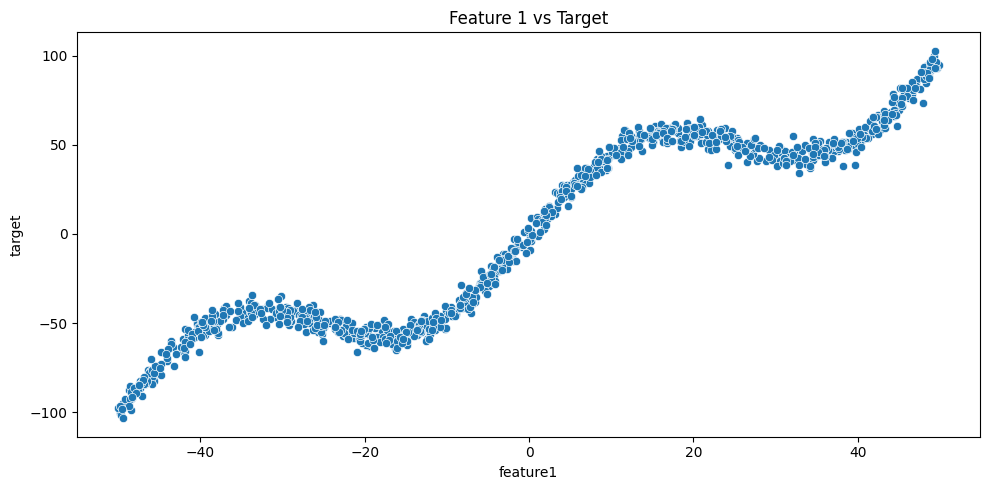

In [40]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x='feature1', y='target')
plt.title('Feature 1 vs Target')
plt.tight_layout()
plt.show()

Dataset ini tidak mengikuti pola linear tradisional karena memiliki komponen sine wave.

### Polynomial regression

In [41]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
X = data[['feature1']]
y = data['target']

# Create a list of polynomial degrees to try
degrees = [1, 2, 3, 4, 5]
results = []

In [43]:
for degree in degrees:
  poly = PolynomialFeatures(degree=degree)
  X_poly = poly.fit_transform(X)

  X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=123)

  poly_model = LinearRegression()
  poly_model.fit(X_train, y_train)

  y_pred = poly_model.predict(X_test)

  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  results.append({
    'Degree': degree,
    'MSE': mse,
    'R2': r2
  })

In [44]:
results_df = pd.DataFrame(results)
print("\nModel Performance Metrics:")
print(results_df.to_string(index=False))


Model Performance Metrics:
 Degree        MSE       R2
      1 317.005037 0.891135
      2 316.818454 0.891199
      3 268.477397 0.907800
      4 268.230101 0.907885
      5  48.316167 0.983407


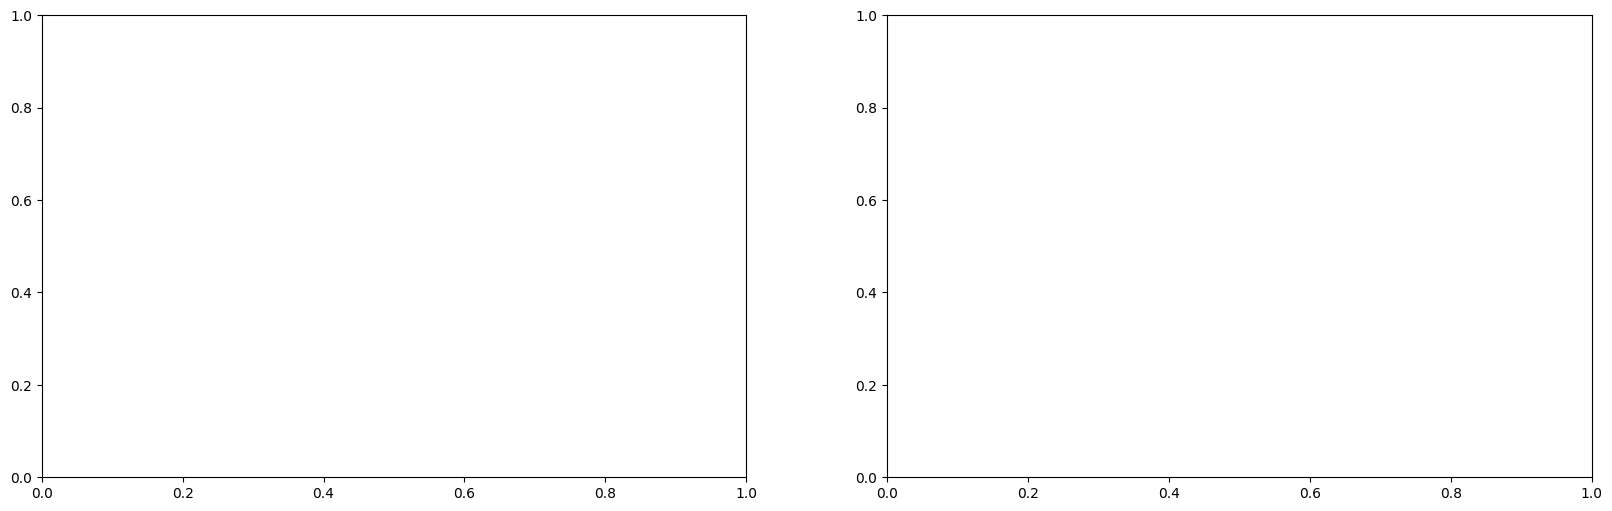

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

In [46]:
ax1.scatter(X['feature1'], y, alpha=0.2, label='Data points')

In [47]:
X_plot = np.linspace(
  X['feature1'].min(),
  X['feature1'].max(), 1000
).reshape(-1, 1)
colors = ['blue', 'green', 'red', 'purple', 'black']
for degree, color in zip(degrees, colors):
  poly = PolynomialFeatures(degree=degree)
  X_plot_poly = poly.fit_transform(X_plot)
  model = LinearRegression()
  model.fit(poly.fit_transform(X), y)
  y_plot = model.predict(X_plot_poly)
  ax1.plot(X_plot, y_plot, label=f'Degree {degree}',
           color=color, linewidth=2)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Target')
ax1.set_title('Polynomial Regression Fits')
ax1.legend(loc='upper left')

In [48]:
best_degree = results_df.loc[
  results_df['R2'].idxmax(), 'Degree']
best_poly = PolynomialFeatures(degree=best_degree)
X_poly_best = best_poly.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
  X_poly_best, y, test_size=0.2, random_state=123)
best_model = LinearRegression()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred
ax2.scatter(y_pred, residuals, alpha=0.5)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Predicted Values')
ax2.set_ylabel('Residuals')
ax2.set_title(
  f'Residual Plot (Best Model: Degree {best_degree})')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

Polynomial regression dapat memodelkan hubungan non-linear dengan membuat fitur polynomial. Namun, pemilihan model tidak cukup hanya melihat MSE dan R² karena model yang terlalu fleksibel dapat mengalami overfitting.

### Spline interpolation

Spline interpolation membuat kurva halus yang melewati sekumpulan titik data. Teknik ini menggunakan piecewise polynomials, yaitu data dibagi menjadi beberapa segmen lalu setiap segmen diberi polynomial sendiri.

In [49]:
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

In [50]:
n_knots = [3, 5, 7]  # Different numbers of knots to try
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SplineTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SplineTransformer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SplineTransformer was fitted with feature names
  warnings.warn(


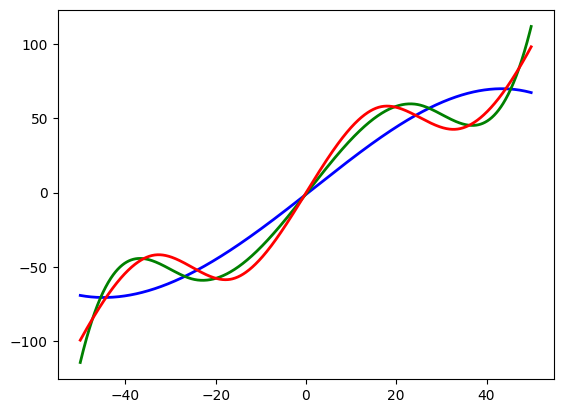

In [51]:
mse_scores = []
r2_scores = []
for n_knot, color in zip(n_knots, colors[:len(n_knots)]):
  spline = SplineTransformer(n_knots=n_knot, degree=3)
  model = make_pipeline(spline, LinearRegression())
  model.fit(X, y)

  y_pred = model.predict(X_plot)
  y_pred_train = model.predict(X)

  mse = mean_squared_error(y, y_pred_train)
  r2 = r2_score(y, y_pred_train)
  mse_scores.append(mse)
  r2_scores.append(r2)

  plt.plot(X_plot, y_pred,
           label=f'Spline (knots={n_knot})',
           color=color,
           linewidth=2)

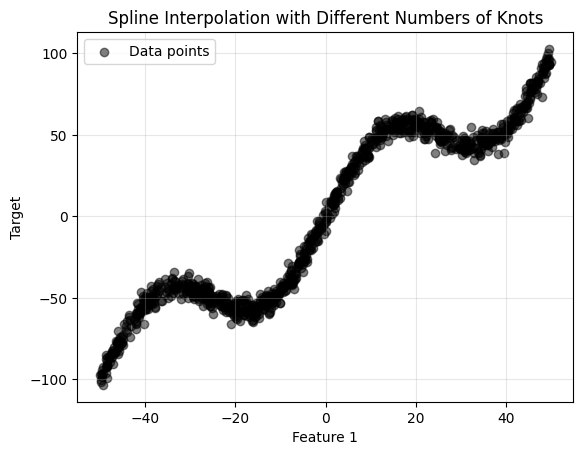

In [52]:
plt.scatter(X, y, color='black', alpha=0.5,
            label='Data points')
plt.xlabel('Feature 1')
plt.ylabel('Target')
plt.title('Spline Interpolation with Different Numbers of Knots')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
metrics_df = pd.DataFrame({
  'Number of Knots': n_knots,
  'MSE': mse_scores,
  'R-squared': r2_scores
})
display(metrics_df)

,Number of Knots,MSE,R-squared
0,3,274.267019,0.904652
1,5,55.347798,0.980759
2,7,15.502097,0.994611


Pada spline regression, semakin banyak knots yang digunakan, model dapat menjadi lebih fleksibel. Pada contoh materi, ketika jumlah knots meningkat, MSE menurun, yang menunjukkan model fit lebih baik.

### How it works

Polynomial regression memperluas linear regression dengan menambahkan bentuk polynomial dari fitur, seperti `x²`, `x³`, dan seterusnya. Dengan begitu, model dapat menangkap hubungan non-linear.

Spline interpolation menggunakan polynomial per segmen. Teknik ini berguna untuk dataset kompleks yang memiliki tren non-linear.

### Hands-on exercises

Alur umum latihan pada bagian ini:

1. Siapkan environment dan library.
2. Load dataset regresi.
3. Lakukan preprocessing jika diperlukan.
4. Load `PolynomialFeatures()` dari `sklearn.preprocessing`.
5. Latih model pada fitur polynomial.
6. Hitung MSE dan R².
7. Load `SplineTransformer()` dari `sklearn.preprocessing`.
8. Latih model dengan training data.
9. Hitung MSE dan R².
10. Analisis performa kedua teknik berdasarkan metrik evaluasi.

## Practical exercises with regularization techniques

Bagian akhir materi memberikan latihan praktik untuk menerapkan Ridge regression, Lasso regression, dan ElasticNet regression. Pada latihan, disarankan menggunakan `random_state=123` atau `np.random.seed(123)` jika diperlukan agar hasil dapat direproduksi.

### Exercise 1: Implementing ridge regression

Langkah implementasi:

1. Load libraries.
2. Generate synthetic dataset dengan noise.
3. Split data menjadi training dan testing set.
4. Buat dan fit Ridge regression model.
5. Buat prediksi.
6. Hitung metrik.
7. Print metrik.
8. Visualisasikan hasil.
9. Sort nilai X untuk membuat smooth line plot.

### Exercise 2: Implementing Lasso regression

Langkah implementasi:

1. Load libraries.
2. Generate synthetic data.
3. Split data menjadi training dan testing set.
4. Buat dan fit Lasso regression model.
5. Buat prediksi.
6. Hitung metrik.
7. Print metrik.
8. Visualisasikan hasil.
9. Sort nilai X untuk membuat smooth line plot.

### Exercise 3: Implementing ElasticNet regression

Langkah implementasi:

1. Load libraries.
2. Generate synthetic data.
3. Split data menjadi training dan testing set.
4. Buat dan fit ElasticNet model.
5. Buat prediksi.
6. Hitung metrik.
7. Print metrik.
8. Visualisasikan hasil.
9. Sort nilai X untuk membuat smooth line plot.